## Long fact ++ exploration notebook
In this notebook we are exploring the longfact++ dataset, from https://huggingface.co/datasets/obalcells/hallucination-heads-longfact.
The reference paper is:
https://arxiv.org/pdf/2509.03531



In [3]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("obalcells/hallucination-heads-longfact", "Meta-Llama-3.1-8B-Instruct")

/home/nicolobrunello/miniconda/envs/bias_rag/lib/python3.12/importlib/__init__.py:90: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  return _bootstrap._gcd_import(name[level:], package, level)


Meta-Llama-3.1-8B-Instruct/test-00000-of(…):   0%|          | 0.00/3.57M [00:00<?, ?B/s]

Meta-Llama-3.1-8B-Instruct/validation-00(…):   0%|          | 0.00/252k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/989 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/64 [00:00<?, ? examples/s]

In [4]:
ds

DatasetDict({
    test: Dataset({
        features: ['conversation', 'verified_entities', 'dataset', 'category', 'model', 'split'],
        num_rows: 989
    })
    validation: Dataset({
        features: ['conversation', 'verified_entities', 'dataset', 'category', 'model', 'split'],
        num_rows: 64
    })
})

In [5]:
ds["test"][0]

{'conversation': [{'content': 'What is the mathematical concept of combinatorics? How does it contribute to areas like cryptography, probability theory, statistical physics, and computer science? Provide as many specific details and examples as possible (such as names of people, numbers, events, locations, dates, times, etc.)\n',
   'role': 'user'},
  {'content': 'Combinatorics is a branch of mathematics that deals with the study of counting and arranging objects in various ways. It involves the use of mathematical techniques to count the number of possible arrangements, permutations, and combinations of objects, and to analyze the properties of these arrangements.\n\n**History of Combinatorics**\n\nThe study of combinatorics dates back to ancient civilizations, with contributions from mathematicians such as:\n\n1. **Pierre-Simon Laplace** (1749-1827): A French mathematician who developed the concept of permutations and combinations.\n2. **Leonhard Euler** (1707-1783): A Swiss mathemat

In [6]:
import numpy as np
np.unique(ds['test']['category'])

array(['biography', 'history', 'legal', 'medical', 'other', 'science'],
      dtype='<U9')

In [7]:
import pandas as pd
pd.DataFrame(ds['test']).value_counts("category")

category
other        712
science      127
legal         56
history       42
medical       37
biography     15
Name: count, dtype: int64

In [8]:
df = pd.DataFrame(ds['test'])
df


,conversation,verified_entities,dataset,category,model,split
0,[{'content': 'What is the mathematical concept...,"[{'idx': 456, 'label': 'Supported', 'text': 'P...",longfact_concepts,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
1,[{'content': 'Can you delve into the notion of...,"[{'idx': 478, 'label': 'Supported', 'text': 'f...",longfact_concepts,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
2,[{'content': 'Can you explain the principles a...,"[{'idx': 2960, 'label': 'Supported', 'text': '...",longfact_concepts,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
3,[{'content': 'What is the significance of grou...,"[{'idx': 4870, 'label': 'Supported', 'text': '...",longfact_concepts,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
4,[{'content': 'Can you delve into the concept o...,"[{'idx': 3728, 'label': 'Supported', 'text': '...",longfact_concepts,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
...,...,...,...,...,...,...
984,[{'content': 'What is the approach behind Goog...,"[{'idx': 1597, 'label': 'Supported', 'text': '...",longfact_objects,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
985,[{'content': 'What is Eliezer Yudkowsky's Mach...,"[{'idx': 181, 'label': 'Supported', 'text': '2...",longfact_objects,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
986,[{'content': 'What can you tell me about the A...,"[{'idx': 313, 'label': 'Supported', 'text': '3...",longfact_objects,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test
987,[{'content': 'What principles does the philoso...,"[{'idx': 244, 'label': 'Supported', 'text': 'C...",longfact_concepts,other,meta-llama/Meta-Llama-3.1-8B-Instruct,test


In [9]:
df['conversation'][0]

[{'content': 'What is the mathematical concept of combinatorics? How does it contribute to areas like cryptography, probability theory, statistical physics, and computer science? Provide as many specific details and examples as possible (such as names of people, numbers, events, locations, dates, times, etc.)\n',
  'role': 'user'},
 {'content': 'Combinatorics is a branch of mathematics that deals with the study of counting and arranging objects in various ways. It involves the use of mathematical techniques to count the number of possible arrangements, permutations, and combinations of objects, and to analyze the properties of these arrangements.\n\n**History of Combinatorics**\n\nThe study of combinatorics dates back to ancient civilizations, with contributions from mathematicians such as:\n\n1. **Pierre-Simon Laplace** (1749-1827): A French mathematician who developed the concept of permutations and combinations.\n2. **Leonhard Euler** (1707-1783): A Swiss mathematician who made sign

I need to create a dataset for each claim with supported vs non supported label.
The pipeline is to 
- split each conversation into sentences
- keep only sentences with an annotated entities
- deduplicate
- Create df with "sentence":str, "label": ["supported", "unsupported"]


In [10]:
list_of_conversations = df['conversation'].tolist()
list_of_conversations[0]

[{'content': 'What is the mathematical concept of combinatorics? How does it contribute to areas like cryptography, probability theory, statistical physics, and computer science? Provide as many specific details and examples as possible (such as names of people, numbers, events, locations, dates, times, etc.)\n',
  'role': 'user'},
 {'content': 'Combinatorics is a branch of mathematics that deals with the study of counting and arranging objects in various ways. It involves the use of mathematical techniques to count the number of possible arrangements, permutations, and combinations of objects, and to analyze the properties of these arrangements.\n\n**History of Combinatorics**\n\nThe study of combinatorics dates back to ancient civilizations, with contributions from mathematicians such as:\n\n1. **Pierre-Simon Laplace** (1749-1827): A French mathematician who developed the concept of permutations and combinations.\n2. **Leonhard Euler** (1707-1783): A Swiss mathematician who made sign

In [11]:
list_of_conversations[0][1]['content'][417:]

'ons from mathematicians such as:\n\n1. **Pierre-Simon Laplace** (1749-1827): A French mathematician who developed the concept of permutations and combinations.\n2. **Leonhard Euler** (1707-1783): A Swiss mathematician who made significant contributions to the field of combinatorics, including the development of the concept of graph theory.\n3. **William Shanks** (1812-1882): An English mathematician who calculated the value of pi to 707 digits using combinatorial methods.\n\n**Applications of Combinatorics**\n\nCombinatorics has numerous applications in various fields, including:\n\n1. **Cryptography**: Combinatorics is used to develop secure encryption algorithms, such as the RSA algorithm, which relies on the difficulty of factoring large numbers into their prime factors.\n2. **Probability Theory**: Combinatorics is used to calculate probabilities of events, such as the probability of winning a lottery or the probability of a coin landing heads up.\n3. **Statistical Physics**: Combi

In [12]:
list_of_entities_objects = df['verified_entities'].tolist()
list_of_entities_objects[0]

[{'idx': 456,
  'label': 'Supported',
  'text': 'Pierre-Simon Laplace',
  'verification_note': 'Pierre-Simon Laplace (1749-1827) was indeed a French mathematician who made significant contributions to probability theory and mathematics.'},
 {'idx': 480,
  'label': 'Supported',
  'text': '1749-1827',
  'verification_note': 'The dates are correct - Laplace was born March 23, 1749 and died March 5, 1827.'},
 {'idx': 519,
  'label': 'Not Supported',
  'text': 'developed the concept of permutations and combinations',
  'verification_note': 'While Laplace worked on probability theory, he did not develop the concept of permutations and combinations. These concepts existed before him, and Jacob Bernoulli published substantial work on permutations and combinations earlier.'},
 {'idx': 580,
  'label': 'Supported',
  'text': 'Leonhard Euler',
  'verification_note': 'Leonhard Euler (1707-1783) was indeed a Swiss mathematician.'},
 {'idx': 598,
  'label': 'Supported',
  'text': '1707-1783',
  'veri

In [11]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/nicolobrunello/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
list_of_sentences = []
list_of_entities = []
list_of_labels = []
list_of_queries = []


for conversation, entities in zip(list_of_conversations, list_of_entities_objects):
    
    for entity in entities:

        # find entity in the conversation, they sould be present in the model answer
        model_answer = [message['content'] for message in conversation if message['role'] == 'assistant'][0]
        
        # if the entity not in model answer, skip
        if entity['text'] not in model_answer:
            print(f"Entity {entity['text']} not in model answer")
            print(f"Model answer: {model_answer}")
            continue
        # if the entity in model answer, get the sentence around the entity
        # split into sentences
        sentences = nltk.tokenize.sent_tokenize(model_answer)
        target_sentence = [sentence for sentence in sentences if entity['text'] in sentence]
        if len(target_sentence) == 0:
            continue
        if len(target_sentence) > 1:
            print(f"More than one sentence found for entity {entity}")
            continue
        target_sentence = target_sentence[0]
        # get the label
        label = entity['label']
        entity_name = entity['text']
        # add to the list
        list_of_sentences.append(target_sentence)
        list_of_entities.append(entity_name)
        list_of_labels.append(label)

df_sentences = pd.DataFrame({"sentence": list_of_sentences, "label": list_of_labels, "entity": list_of_entities})
df_sentences



More than one sentence found for entity {'idx': 5897, 'label': 'Supported', 'text': 'John Hay', 'verification_note': 'Confirmed as U.S. Secretary of State who introduced the Open Door Policy'}
Entity July 3, 1900 not in model answer
Model answer: The Open Door Policy, introduced by the United States in the late 19th and early 20th centuries, was a diplomatic initiative aimed at promoting equal access to Chinese markets and resources for all foreign powers, while preventing any single country from dominating China. This policy had significant implications for U.S.-China relations, as well as the interests of other major powers in China, and ultimately shaped China's political and economic development.

**Background and Introduction (1899-1900)**

In the late 19th century, China was facing intense pressure from European powers, including Britain, France, Germany, and Russia, which were seeking to expand their colonial empires and gain control over Chinese territories and resources. The U

,sentence,label,entity
0,"The conference, which took place from July 1 t...",Supported,"July 1 to July 22, 1944"
1,"The conference, which took place from July 1 t...",Supported,44 countries
2,The Bretton Woods system was the brainchild of...,Supported,Harry Dexter White
3,The Bretton Woods system was the brainchild of...,Supported,John Maynard Keynes
4,**Fixed exchange rates**: Countries agreed to ...,Supported,$35 per ounce
...,...,...,...
19392,"For example, the deregulation of the airline i...",Supported,deregulation of the airline industry in the Un...
19393,"For example, the deregulation of the airline i...",Supported,led by Senator Ted Kennedy and President Jimmy...
19394,"For example, the economic growth in Singapore,...",Insufficient Information,"Singapore, driven by incentives such as low ta..."
19395,"For instance, the job market in Germany, drive...",Insufficient Information,unemployment rate of around 3.2% in 2020


In [13]:
df_sentences['label'].value_counts()

label
Supported                   12973
Insufficient Information     3745
Not Supported                2679
Name: count, dtype: int64

## Normalization
To normalize the dataset we need:
- "question"
- "factual answer"
- "non factual answer"
- factual evidence
- non factual evidence
- gound_truth

In [14]:
# plot number of questions per number of false entities
pairs = []
for conversation, entity_objects in zip(list_of_conversations, list_of_entities_objects):
    for entity in entity_objects:
        number_of_false_entities = len([e for e in entity_objects if e['label'] == 'Not Supported'])
        pairs.append((conversation, number_of_false_entities))
        

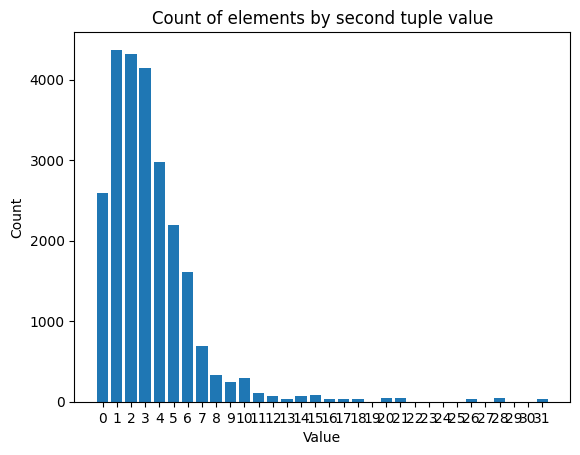

In [15]:
from collections import Counter
import matplotlib.pyplot as plt

data = pairs

# Count occurrences of each integer value
counts = Counter(val for _, val in data)

# Fill in missing values with 0
max_val = max(counts)
x = list(range(max_val + 1))
y = [counts.get(i, 0) for i in x]

plt.bar(x, y)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Count of elements by second tuple value")
plt.xticks(x)  # ensure 0, 1, 2, 3... labels
plt.show()

In [16]:
# deduplicate the dataset, now we have many duplciated sentences, one for each entity
# keep only sentences with all true entities (supported) or all false entities (not supported)

import pandas as pd

# --- Step 1: dedupe — keep one row per sentence only if all entity labels agree ---
records = []
for sentence, group in df_sentences.groupby('sentence', sort=False):
    labels = group['label'].unique()
    if len(labels) == 1:
        records.append({
            'sentence': sentence,
            'label': labels[0],
            'entities': list(group['entity'])
        })
    # else: mixed labels for this sentence -> discard entirely

df_dedup = pd.DataFrame(records)
print("Before balancing:")
print(df_dedup['label'].value_counts())

# --- Step 2: balance across the 3 classes (Supported / Not Supported / Insufficient Information) ---
min_count = df_dedup['label'].value_counts().min()

df_balanced = (
    df_dedup
    .groupby('label', group_keys=False)
    .apply(lambda g: g.sample(n=min_count, random_state=42))
    .reset_index(drop=True)
)

print("\nAfter balancing:")
print(df_balanced['label'].value_counts())

Before balancing:
label
Supported                   6755
Insufficient Information    2037
Not Supported               1234
Name: count, dtype: int64

After balancing:
label
Insufficient Information    1234
Not Supported               1234
Supported                   1234
Name: count, dtype: int64


/tmp/ipykernel_3038224/3055720233.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min_count, random_state=42))


In [17]:
df_balanced

,sentence,label,entities
0,**Outlines of Lectures on Jurisprudence** (192...,Insufficient Information,[Outlines of Lectures on Jurisprudence** (1921]
1,They recruited 72 male students from New York ...,Insufficient Information,"[72 male students, New York University (NYU)]"
2,"Additionally, a study by AdRoll found that ret...",Insufficient Information,"[increase customer engagement by 25%, reduce c..."
3,"The statement, attributed to United Airlines C...",Insufficient Information,[10:30 PM CDT on April 9]
4,The commercial was directed by renowned direct...,Insufficient Information,[Tony Scott]
...,...,...,...
3697,"On July 1, 1973, FASB issued its first stateme...",Supported,"[July 1, 1973]"
3698,"For example, a star called S2 (also known as S...",Supported,[17 light-hours]
3699,**The North Korean Embassy in Spain**: In 2019...,Supported,[armed men stormed the North Korean Embassy in...
3700,"As the Nile continues its journey, it flows in...",Supported,[700 kilometers (435 miles)]
